# Bloc 03 - Conversion rate challenge

## 02 - Baseline

### Import libraries

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from IPython.display import Image, display
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Choix des variables

In [2]:
data = pd.read_csv("../data/conversion_data_train_cleaned.csv")

In [3]:
target_variable = 'converted'
X = data.drop(columns=target_variable)
y = data[target_variable]

numeric_columns = ["age", "total_pages_visited"]
cat_columns = ["new_user", "country", "source"]

features_list = numeric_columns + cat_columns

print(numeric_columns, cat_columns)
print(features_list)

['age', 'total_pages_visited'] ['new_user', 'country', 'source']
['age', 'total_pages_visited', 'new_user', 'country', 'source']


### Train set & Test set

In [4]:
print("Dividing into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



### Preprocessing

In [5]:
print("Encoding categorical features and standardizing numerical features...")

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

cat_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(drop="first"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", cat_transformer, cat_columns)
    ]
)

Encoding categorical features and standardizing numerical features...


### Application du preprocessing sur train

In [6]:
X_train = preprocessor.fit_transform(X_train)
print("...Done")
print(X_train[0:5,:])

...Done
[[ 1.53857988 -0.22471238  0.          0.          0.          1.
   0.          1.        ]
 [-0.06432332 -0.22471238  1.          0.          0.          1.
   0.          1.        ]
 [-0.06432332 -0.22471238  0.          0.          0.          0.
   1.          0.        ]
 [-0.5575243   0.46933878  1.          0.          0.          1.
   1.          0.        ]
 [-0.68082455 -0.57173795  1.          0.          0.          1.
   0.          1.        ]]


### Application du preprocessing sur test

In [7]:
X_test = preprocessor.transform(X_test)
print("...Done")
print(X_test[0:5,:])

...Done
[[ 2.27838135 -0.91876353  1.          0.          0.          1.
   0.          1.        ]
 [-0.43422406 -1.26578911  0.          0.          0.          1.
   0.          1.        ]
 [-1.54392627 -1.26578911  1.          0.          0.          1.
   0.          0.        ]
 [-0.18762357 -1.26578911  1.          0.          0.          0.
   0.          1.        ]
 [-0.80412479 -0.22471238  1.          0.          0.          0.
   0.          0.        ]]


### Modèle

In [8]:
# Train model
print("Train model...")
classifier = LogisticRegression()
classifier.fit(X_train, y_train)
print("...Done.")

Train model...
...Done.


### Prédiction sur le training set

In [9]:
# Predictions on training set
print("Predictions on training set...")
y_train_pred = classifier.predict(X_train)
print("...Done.")
print(y_train_pred)
print()

Predictions on training set...
...Done.
[0 0 0 ... 0 0 0]



### Prédiction sur le test set

In [10]:
# Predictions on test set
print("Predictions on test set...")
y_test_pred = classifier.predict(X_test)
print("...Done.")
print(y_test_pred)
print()

Predictions on test set...
...Done.
[0 0 0 ... 0 0 0]



### Evaluation des performances

In [11]:
print("f1-score on train set : ", f1_score(y_train, y_train_pred, average="macro"))
print("f1-score on test set : ", f1_score(y_test, y_test_pred, average="macro"))

f1-score on train set :  0.7465135670874515
f1-score on test set :  0.7473681931881306


In [12]:
# Print classification report:
print('Classification report on train set:')
print(classification_report(y_train, y_train_pred))

print('Classification report on test set:')
print(classification_report(y_test, y_test_pred))

Classification report on train set:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    219085
           1       0.71      0.38      0.50      3674

    accuracy                           0.99    222759
   macro avg       0.85      0.69      0.75    222759
weighted avg       0.99      0.99      0.99    222759

Classification report on test set:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     54771
           1       0.73      0.38      0.50       919

    accuracy                           0.99     55690
   macro avg       0.86      0.69      0.75     55690
weighted avg       0.99      0.99      0.99     55690



Le modèle reconnaît bien la classe 0.  

Pour la classe 1,
precision de 71-73%: le modèle a raison pour 71% du temps  
71-73% des utilisateurs vont réellement souscrire à la newsletter.

recall de 38%: le modèle ne détecte que 38% de vrais positif --> il rate 62% de cas positifs  
Le modèle n'identifie que 38% des utilisateurs qui souscrivent à la newsletter.

accuracy de 99%: le modèle prédit toujours la classe 0.

In [13]:
# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(y_train, y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(y_test, y_test_pred))
print()

Confusion matrix on train set : 
[[218511    574]
 [  2260   1414]]

Confusion matrix on test set : 
[[54643   128]
 [  569   350]]



### Analyse des features

In [14]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['num__age', 'num__total_pages_visited', 'cat__new_user_1',
       'cat__country_Germany', 'cat__country_UK', 'cat__country_US',
       'cat__source_Direct', 'cat__source_Seo'], dtype=object)

In [15]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": classifier.coef_[0],
    "coefficient_abs": abs(classifier.coef_[0])

}).sort_values(by="coefficient_abs", key=abs, ascending=False)

print(coef_df)

                    feature  coefficient  coefficient_abs
3      cat__country_Germany     3.344066         3.344066
4           cat__country_UK     3.020660         3.020660
5           cat__country_US     2.701012         2.701012
1  num__total_pages_visited     2.177390         2.177390
2           cat__new_user_1    -1.677654         1.677654
0                  num__age    -0.610068         0.610068
6        cat__source_Direct    -0.095865         0.095865
7           cat__source_Seo     0.049373         0.049373


In [18]:
def show_images(fig, filename):
    fig.write_image(filename)
    display(Image(filename))

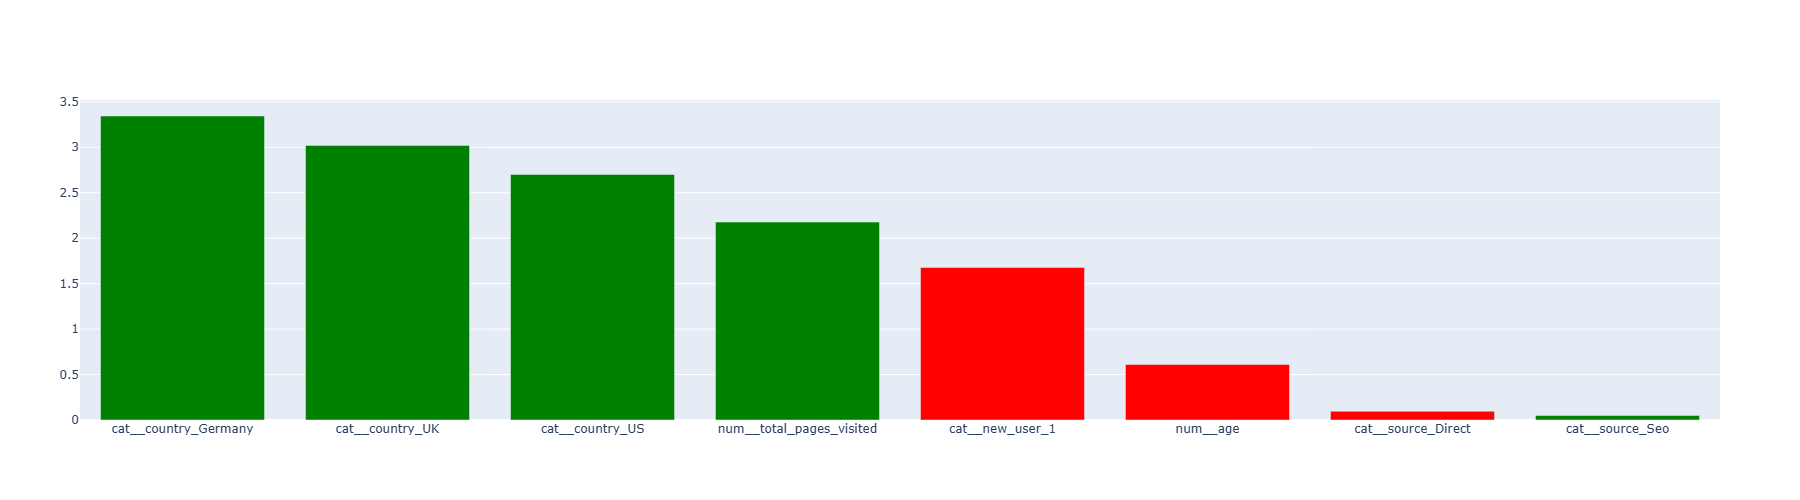

In [19]:
feat_importance_fig = go.Figure()

for idx, row in coef_df.iterrows():
    feat_importance_fig.add_trace(go.Bar(
        x=[row['feature']],
        y=[row['coefficient_abs']],
        marker_color='green' if row['coefficient'] >= 0 else 'red',
        showlegend=False
    ))
feat_importance_fig.update_layout(width=1800, height=500)
feat_importance_fig.show()

show_images(feat_importance_fig, "../images/feat_importance_fig.png")

Les features country ont le plus de poids pour ce modèle.  
Ensuite vient le total_pages_visited.